### 환경 확인

In [1]:
import copy
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt



print("torch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
device: cuda
gpu: NVIDIA RTX A6000


### 재현성 & 임의 데이터 생성

In [2]:
torch.manual_seed(42)

num_train = 8192
num_eval = 2048

in_features = 128
out_features = 64

group_size = 32

X_train = torch.randn(num_train, in_features, device=device)
X_eval = torch.randn(num_eval, in_features, device=device)

teacher = nn.Linear(in_features, out_features).to(device)

with torch.no_grad():
    y_train = teacher(X_train)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: torch.Size([8192, 128])
y_train: torch.Size([8192, 64])


### Floating-Point 32 bit Linear 모델 학습
단, 여기서 데이터는 임의의 텐서를 사용함

In [3]:
#model_fp = nn.Linear(in_features, out_features).to(device)

model_fp = nn.Sequential(
    nn.Linear(in_features, in_features // 2),
    nn.Linear(in_features // 2, in_features // 2),
    nn.Linear(in_features // 2, in_features // 2),
    nn.Linear(in_features // 2, out_features),
).cuda()

optimizer = torch.optim.AdamW(model_fp.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 500

model_fp.train()

for epoch in range(epochs):
    pred = model_fp(X_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:4d} | loss = {loss.item():.6f}")

epoch  100 | loss = 0.062501
epoch  200 | loss = 0.018679
epoch  300 | loss = 0.008527
epoch  400 | loss = 0.005497
epoch  500 | loss = 0.003821


### FP32 layer의 weight, bias 값 확인 및 저장
중간 hidden layer 중 1번째 layer 사용

In [4]:
model_fp.eval()

with torch.no_grad():
    y_fp = model_fp(X_eval)

# Sequential 안의 모든 Linear layer weight를 저장
fp_linear_weights = {}

for name, module in model_fp.named_modules():
    if isinstance(module, nn.Linear):
        fp_linear_weights[name] = module.weight.detach().float().cpu()

print("FP output shape:", y_fp.shape)
print("Linear layers:")
for name, w in fp_linear_weights.items():
    print(f"  {name}: {tuple(w.shape)}")

FP output shape: torch.Size([2048, 64])
Linear layers:
  0: (64, 128)
  1: (64, 64)
  2: (64, 64)
  3: (64, 64)


### quant&dequant function

In [5]:
def symmetric_quant_dequant_weight(w_fp: torch.Tensor, num_bits: int):
    """
    Raw PyTorch symmetric uniform quantization.

    - signed integer range 사용
    - weight-only quantization 실험용
    - 반환값은 dequantized float tensor
    """
    assert w_fp.dtype == torch.float32
    assert 2 <= num_bits <= 8

    # signed symmetric range
    qmax = 2 ** (num_bits - 1) - 1
    qmin = -qmax

    max_abs = w_fp.abs().max()

    if max_abs == 0:
        scale = torch.tensor(1.0, device=w_fp.device, dtype=torch.float32)
        w_int = torch.zeros_like(w_fp, dtype=torch.int32)
        w_dequant = torch.zeros_like(w_fp)
        return w_dequant, w_int, scale

    scale = max_abs / qmax

    # quantize
    w_int = torch.round(w_fp / scale)
    w_int = torch.clamp(w_int, qmin, qmax).to(torch.int32)

    # dequantize
    w_dequant = w_int.float() * scale

    return w_dequant, w_int, scale

def make_weight_quantized_mlp(model_fp: nn.Module, num_bits: int):
    """
    FP32 MLP를 deepcopy한 뒤,
    모든 nn.Linear layer의 weight만 quantize-dequantize해서 넣는다.

    bias는 FP32 그대로 유지.
    """
    q_model = copy.deepcopy(model_fp).eval().float()

    layer_weight_stats = []

    with torch.no_grad():
        for name, module in q_model.named_modules():
            if isinstance(module, nn.Linear):
                w_fp = module.weight.data.float()

                w_dequant, w_int, scale = symmetric_quant_dequant_weight(
                    w_fp=w_fp,
                    num_bits=num_bits,
                )

                weight_error = w_dequant - w_fp

                module.weight.data.copy_(w_dequant)

                layer_weight_stats.append({
                    "bit": num_bits,
                    "layer": name,
                    "weight_shape": tuple(w_fp.shape),
                    "scale": scale.item(),
                    "weight_error_mean": weight_error.mean().item(),
                    "weight_error_variance": weight_error.var(unbiased=False).item(),
                    "weight_error_std": weight_error.std(unbiased=False).item(),
                    "weight_mse": torch.mean(weight_error ** 2).item(),
                    "weight_int_min": int(w_int.min().item()),
                    "weight_int_max": int(w_int.max().item()),
                })

    return q_model, layer_weight_stats

### Visualization

In [6]:
bits_list = [8, 7, 6, 5, 4, 3, 2]

model_results = []
layer_results = []
quantized_models = {}

for bit in bits_list:
    print(f"[run] {bit}-bit weight quantization")

    q_model, layer_stats = make_weight_quantized_mlp(model_fp, bit)

    with torch.no_grad():
        y_q = q_model(X_eval)

    output_error = y_q.float() - y_fp.float()

    model_results.append({
        "bit": bit,
        "output_error_mean": output_error.mean().item(),
        "output_error_variance": output_error.var(unbiased=False).item(),
        "output_error_std": output_error.std(unbiased=False).item(),
        "output_mse": torch.mean(output_error ** 2).item(),
    })

    layer_results.extend(layer_stats)
    quantized_models[bit] = q_model

model_df = pd.DataFrame(model_results)
layer_df = pd.DataFrame(layer_results)

display(model_df)
display(layer_df)

[run] 8-bit weight quantization
[run] 7-bit weight quantization
[run] 6-bit weight quantization
[run] 5-bit weight quantization
[run] 4-bit weight quantization
[run] 3-bit weight quantization
[run] 2-bit weight quantization


,bit,output_error_mean,output_error_variance,output_error_std,output_mse
0,8,-0.000033,0.000062,0.007868,0.000062
1,7,0.000030,0.000265,0.016267,0.000265
2,6,0.000645,0.001063,0.032611,0.001064
3,5,0.000564,0.004692,0.068500,0.004693
4,4,-0.003874,0.022088,0.148622,0.022103
5,3,0.002563,0.134388,0.366590,0.134395
6,2,-0.012577,0.995697,0.997846,0.995856


,bit,layer,weight_shape,scale,weight_error_mean,weight_error_variance,weight_error_std,weight_mse,weight_int_min,weight_int_max
0,8,0,"(64, 128)",0.002139,3.747738e-06,3.791879e-07,0.000616,3.792019e-07,-115,127
1,8,1,"(64, 64)",0.002408,1.475141e-05,4.872256e-07,0.000698,4.874432e-07,-124,127
2,8,2,"(64, 64)",0.002512,-1.056427e-05,5.276673e-07,0.000726,5.277789e-07,-120,127
3,8,3,"(64, 64)",0.002238,-6.259268e-07,4.110895e-07,0.000641,4.110899e-07,-127,120
4,7,0,"(64, 128)",0.004313,-7.535388e-06,1.558860e-06,0.001249,1.558916e-06,-57,63
5,7,1,"(64, 64)",0.004853,3.675085e-05,1.997405e-06,0.001413,1.998756e-06,-61,63
6,7,2,"(64, 64)",0.005064,-4.869049e-06,2.162696e-06,0.001471,2.162719e-06,-60,63
7,7,3,"(64, 64)",0.004511,3.943567e-06,1.699242e-06,0.001304,1.699257e-06,-63,60
8,6,0,"(64, 128)",0.008764,-4.669544e-05,6.332660e-06,0.002516,6.334840e-06,-28,31
9,6,1,"(64, 64)",0.009863,1.679925e-05,8.083007e-06,0.002843,8.083290e-06,-30,31


In [7]:
display(
    layer_df[
        [
            "bit",
            "layer",
            "weight_shape",
            "scale",
            "weight_error_variance",
            "weight_mse",
            "weight_int_min",
            "weight_int_max",
        ]
    ].sort_values(["layer", "bit"], ascending=[True, False])
)

,bit,layer,weight_shape,scale,weight_error_variance,weight_mse,weight_int_min,weight_int_max
0,8,0,"(64, 128)",0.002139,3.791879e-07,3.792019e-07,-115,127
4,7,0,"(64, 128)",0.004313,1.558860e-06,1.558916e-06,-57,63
8,6,0,"(64, 128)",0.008764,6.332660e-06,6.334840e-06,-28,31
12,5,0,"(64, 128)",0.018113,2.728378e-05,2.730216e-05,-14,15
16,4,0,"(64, 128)",0.038813,1.246012e-04,1.246070e-04,-6,7
20,3,0,"(64, 128)",0.090564,6.793452e-04,6.793896e-04,-3,3
24,2,0,"(64, 128)",0.271691,5.101398e-03,5.101614e-03,-1,1
1,8,1,"(64, 64)",0.002408,4.872256e-07,4.874432e-07,-124,127
5,7,1,"(64, 64)",0.004853,1.997405e-06,1.998756e-06,-61,63
9,6,1,"(64, 64)",0.009863,8.083007e-06,8.083290e-06,-30,31


In [8]:
layer_summary_df = (
    layer_df
    .groupby("bit", as_index=False)
    .agg(
        mean_weight_error_variance=("weight_error_variance", "mean"),
        mean_weight_mse=("weight_mse", "mean"),
        mean_scale=("scale", "mean"),
    )
    .sort_values("bit", ascending=False)
)

display(layer_summary_df)

,bit,mean_weight_error_variance,mean_weight_mse,mean_scale
6,8,4.512926e-07,4.513785e-07,0.002324
5,7,1.854550e-06,1.854912e-06,0.004685
4,6,7.598510e-06,7.599134e-06,0.009521
3,5,3.236520e-05,3.237814e-05,0.019677
2,4,1.498129e-04,1.498795e-04,0.042166
1,3,8.075947e-04,8.077729e-04,0.098387
0,2,7.423695e-03,7.425538e-03,0.295162


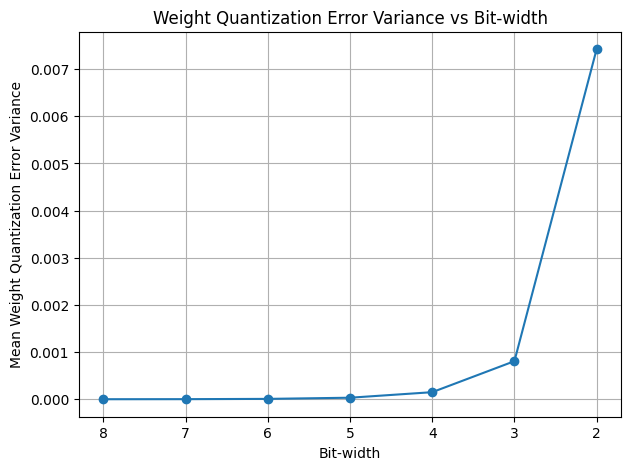

In [9]:
plot_df = layer_summary_df.sort_values("bit", ascending=False)

plt.figure(figsize=(7, 5))
plt.plot(
    plot_df["bit"],
    plot_df["mean_weight_error_variance"],
    marker="o",
)
plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Mean Weight Quantization Error Variance")
plt.title("Weight Quantization Error Variance vs Bit-width")
plt.grid(True)
plt.show()

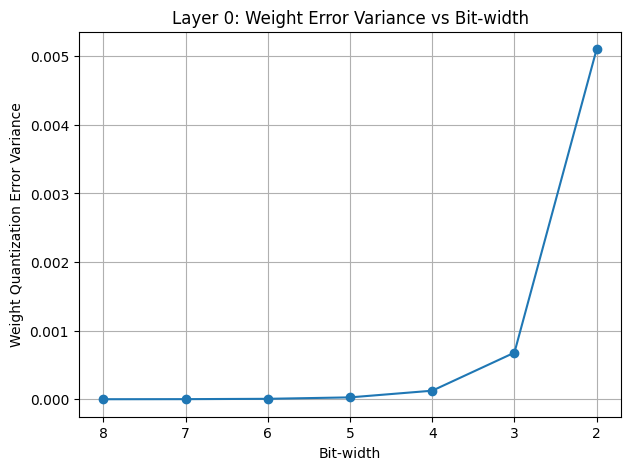

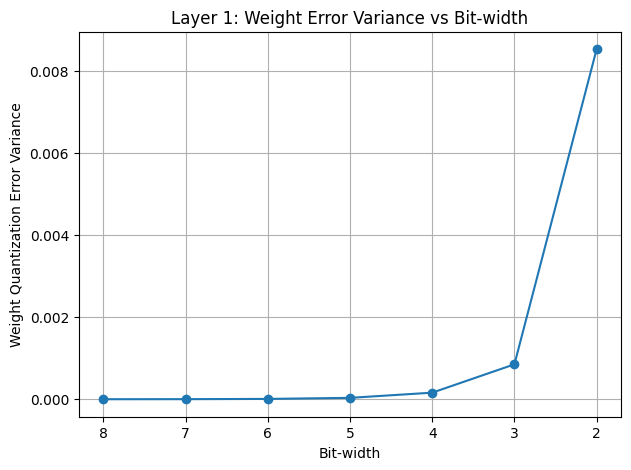

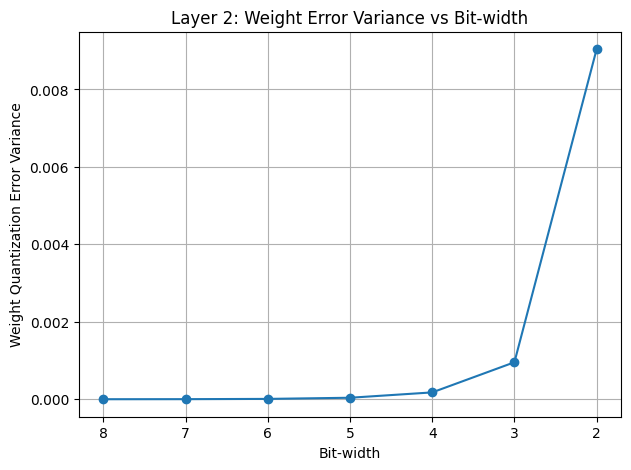

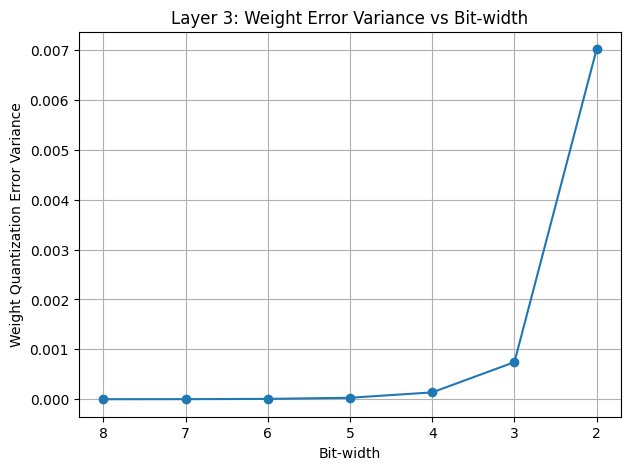

In [10]:
for layer_name in sorted(layer_df["layer"].unique()):
    temp = layer_df[layer_df["layer"] == layer_name].copy()
    temp = temp.sort_values("bit", ascending=False)

    plt.figure(figsize=(7, 5))
    plt.plot(
        temp["bit"],
        temp["weight_error_variance"],
        marker="o",
    )
    plt.gca().invert_xaxis()
    plt.xlabel("Bit-width")
    plt.ylabel("Weight Quantization Error Variance")
    plt.title(f"Layer {layer_name}: Weight Error Variance vs Bit-width")
    plt.grid(True)
    plt.show()

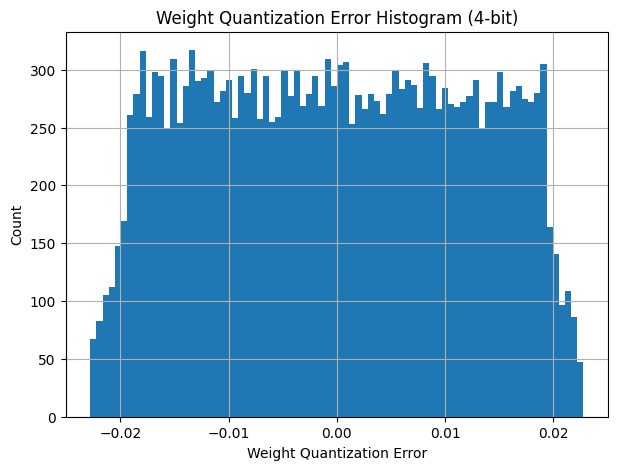

mean: -0.00010201075201621279
variance: 0.00014481457765214145
std: 0.012033892795443535


In [11]:
target_bit = 4

q_model, _ = make_weight_quantized_mlp(model_fp, target_bit)

all_weight_errors = []

with torch.no_grad():
    for name, module_q in q_model.named_modules():
        if isinstance(module_q, nn.Linear):
            module_fp = dict(model_fp.named_modules())[name]

            w_fp = module_fp.weight.data.float()
            w_q = module_q.weight.data.float()

            err = (w_q - w_fp).detach().cpu().flatten()
            all_weight_errors.append(err)

all_weight_errors = torch.cat(all_weight_errors)

plt.figure(figsize=(7, 5))
plt.hist(all_weight_errors.numpy(), bins=80)
plt.xlabel("Weight Quantization Error")
plt.ylabel("Count")
plt.title(f"Weight Quantization Error Histogram ({target_bit}-bit)")
plt.grid(True)
plt.show()

print("mean:", all_weight_errors.mean().item())
print("variance:", all_weight_errors.var(unbiased=False).item())
print("std:", all_weight_errors.std(unbiased=False).item())